# Import packages

In [1]:
import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
ch = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
ch.setFormatter(formatter)
logger.addHandler(ch)

In [2]:
import pylevin as levin
import numpy as np
import pyccl as ccl
import time
import matplotlib.pyplot as plt
import scipy as sp

# Try out integration with Hankel

In [3]:
cosmology_dict = {'Omega_c': 0.27, 'Omega_b': 0.045, 'h': 0.67, 'A_s': 2.1e-09, 'n_s': 0.96}

# k-range for the power spectrum integration. The humongous kmax is a numerical necessity at the moment, but does not affect the results
# rel_eps is the allowed relative error in the integration before it is stopped. n_spline is the number of points in the spline interpolation.
# Best to keep your hands away from this. rel_eps=1e-5 and n_spline=300 is safe, but slow.
integration_options= {'kmin': 1e-5, 'kmax': 500, 'rel_eps': 1e-05, 'n_spline': 300}

# The redshifts at which correlations will be calculated. This has to be a list.
redshift = [0.]

# The scale range at which the correlation will be calculated. The range should be in Mpc/h. (Obligatory *insert swear word of choice here* little h)
# The range should be at least slightly larger than the data range.
interpolation_settings = {'r_min_over_h': 1, 'r_max_over_h': 60, 'number_of_points': 20}

# This are parameters for multipole estimation. Leave them if you are just interested in projection # ALSO DEPRECATED SINCE WE USE HANKEL TRANSFORM NOW
multipoles_options = {'mu_r_spline_number':50, 'perpendicular_scale_cut_over_h': 0.1}

# Properties of the simulation in use. As of now this is only pi_max_over_h, which is the maximum value of the line of sight separation in Mpc/h.
simulation_settings = {'pi_max_over_h': 50}

# Working directory
workdir = '.'

# Path to store calculated predictions for faster subsequent runs
sim_outputdir = './DR1_WL_3/example_output'

# Number of cores to use for calculating the predictions
n_cores = 1

## Using pylevin for multipole

In [4]:
cosmo = ccl.Cosmology(**cosmology_dict)
redshift = 0
scale_factor = 1/(1+redshift)
rmin = interpolation_settings['r_min_over_h'] / cosmology_dict['h']
rmax = interpolation_settings['r_max_over_h'] / cosmology_dict['h']

# rmin = 0.1 / cosmology_dict['h']
# rmax = 40 / cosmology_dict['h']

k_length = 500
k = np.geomspace(1e-5,1000,k_length) #define support
integrand = ccl.nonlin_matter_power(cosmo, k, a=scale_factor)
integrand *= k**2

# Filter out k below cutoff
integrand[k < integration_options['kmin']] = 0

C1rhocrit = 0.0134
scaling = C1rhocrit*cosmo['Omega_m']/2/(np.pi**2)/ccl.growth_factor(cosmo, scale_factor)/3

integrand = integrand[:,None]*scaling

In [5]:
integral_type = 0 
N_thread = 1 # Number of threads used for hyperthreading
logx = True # Tells the code to create a logarithmic spline in x for f(x)
logy = True # Tells the code to create a logarithmic spline in y for y = f(x)
lp_single = levin.pylevin(integral_type, k, integrand, logx, logy, N_thread) #Constructor of the class

In [6]:
n_sub = 12 #number of collocation points in each bisection
n_bisec_max = 32 #maximum number of bisections used
rel_acc = 1e-12 #relative accuracy target
boost_bessel = True #should the bessel functions be calculated with boost instead of GSL, higher accuracy at high Bessel orders
verbose = False #should the code talk to you?
lp_single.set_levin(n_sub, n_bisec_max, rel_acc, boost_bessel, verbose)

In [7]:
M = 200 #number of arguments at which the integrals are evaluated
# r = np.geomspace(rmin,rmax,M)
r = np.geomspace(1e-1, 200, M)
ell = (2*np.ones_like(r)).astype(int) #order of the Bessel function, needs to be an integer
t0 = time.time()
result_levin = np.zeros((M, 1)) #allocate the result
lp_single.levin_integrate_bessel_single(k[0]*np.ones_like(r), k[-1]*np.ones_like(r), r, ell, result_levin)

# Transforming into projections
# Define Pi array (LOS distance in configuration space) that will be integrated over
pi_max = simulation_settings['pi_max_over_h'] / cosmology_dict["h"]
Pi_arr = np.geomspace(1e-5, pi_max, 100)

r_total = np.sqrt(r[:,None]**2 + Pi_arr[None,:]**2)
r_total_flat = r_total.flatten()

# Get multipoles
# Without RSD, only ell=s=2 contributes. Otherwise ell=s=4 becomes important
# See Singh et al 2023 for more information (https://arxiv.org/pdf/2307.02545v1)
# Interpolate to flattened r_total
xi_gp_22_interp = np.interp(r_total_flat, r, result_levin[:,0])
xi_gp_22_shape = xi_gp_22_interp.reshape(r_total.shape)

# Scale with legendre function
legendre_2 = sp.special.assoc_legendre_p(2, 2, Pi_arr/r_total)[0]
integrand_2 = xi_gp_22_shape*legendre_2

# # Integrate over Pi
wgp_levin = (2*np.trapz(integrand_2, Pi_arr, axis=1))

time_levin = time.time()-t0
print("Levin took", time_levin, "s")


Levin took 0.6026842594146729 s


/tmp/ipykernel_227495/3424555315.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  wgp_levin = (2*np.trapz(integrand_2, Pi_arr, axis=1))


## Using old class

In [8]:
from DR1_WL_3.calculate_prediction_base import fitIntrinsicAlignmentAmplitude

t0 = time.time()

prediction_calculator = fitIntrinsicAlignmentAmplitude(
    cosmology_dict=cosmology_dict, 
    integration_options=integration_options, 
    redshift=[0.0], 
    interpolation_settings=interpolation_settings, 
    multipoles_options=multipoles_options,
    simulation_settings=simulation_settings, 
    logger=logger,
    workdir=workdir,
    sim_outputdir=sim_outputdir,
    )

# Simulate the model for later use. Takes roughly 2 min per redshift, but only needs to be done once.
# EXCEPT IF YOU CHANGE CLASS INPUT PARAMETERS AND THE CODE DOES NOT CHECK FOR THIS. If you do, then put resimulate=True
resimulate=False
# prediction_calculator.simulate_projection(resimulate=resimulate, projection_type='gp', n_cores=n_cores)
# prediction_calculator.simulate_projection(resimulate=resimulate, projection_type='gg', n_cores=n_cores)

# currently only the gp22 multipole is implemented.
prediction_calculator.simulate_xi_gp22(resimulate=resimulate, n_cores=n_cores)
# prediction_calculator.simulate_projection(resimulate=resimulate, projection_type='gp', n_cores=5)

time_period_integration = time.time()-t0
print("Period integration took", time_period_integration, "s")

2026-03-11 16:49:05,815 - __main__ - INFO - Initialising intrinsic alignment amplitude simulation and fitter class
2026-03-11 16:49:05,818 - __main__ - DEBUG - Initialised cosmology with parameters: {'Omega_c': 0.27, 'Omega_b': 0.045, 'h': 0.67, 'A_s': 2.1e-09, 'n_s': 0.96}
2026-03-11 16:49:06,778 - __main__ - WARNING - Settings file ././DR1_WL_3/example_output/settings.txt already exists.
2026-03-11 16:49:06,779 - __main__ - INFO - Settings file will not be overwritten. If you want to, set overwrite_settings=True during initialisation
2026-03-11 16:49:06,782 - __main__ - INFO - File ././DR1_WL_3/example_output/xi_gp22_z0.0.txt already exists. Skipping redshift 0.0.


Period integration took 0.9687297344207764 s


In [9]:
r_period, xi_period = prediction_calculator.load_xi_gp22(0.0)
r_period, wgp_period = prediction_calculator.load_projection(0.0, projection_type='gp')
r_period, wgg_period = prediction_calculator.load_projection(0.0, projection_type='gg')

## Plotting difference

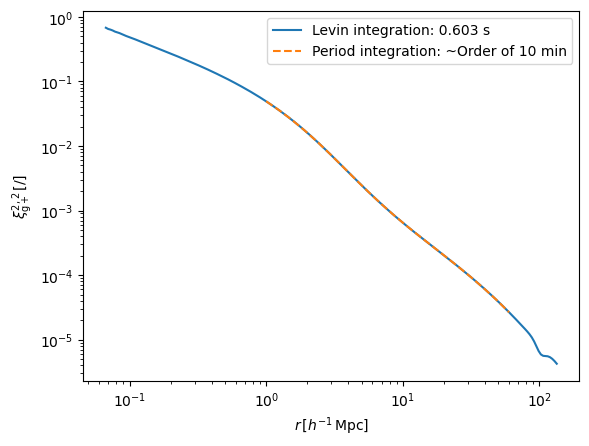

In [10]:
plt.loglog(r*cosmology_dict['h'], result_levin, label=f"Levin integration: {time_levin:.3} s")
plt.loglog(r_period, xi_period, '--', label=f"Period integration: ~Order of 10 min")
plt.legend()
plt.xlabel(r'$r\,[h^{-1}\,$Mpc]')
plt.ylabel(r'$\xi^{2,2}_{\mathrm{g}+}\,$[/]')
plt.show()
plt.close()

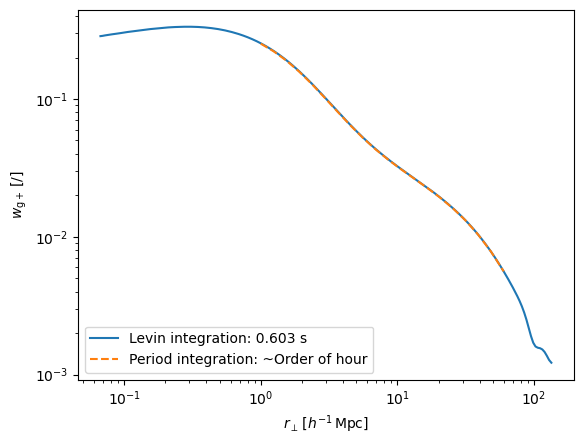

In [11]:
plt.loglog(r*cosmology_dict['h'], wgp_levin*cosmology_dict['h'], label=f"Levin integration: {time_levin:.3} s")
plt.loglog(r_period, wgp_period, '--', label=f"Period integration: ~Order of hour")
plt.legend()
plt.xlabel(r'$r_\perp\,[h^{-1}\,$Mpc]')
plt.ylabel(r'$w_{\mathrm{g}+}\,$[/]')
plt.show()
plt.close()

### Load w_pp from Casper

In [12]:
path_to_wpp_0 = './tmp/casper_wpp/w_pp0_model_storage_large_grid25/w_gp_z0.0.txt'
path_to_wpp_4 = './tmp/casper_wpp/w_pp4_model_storage_large_grid25/w_gp_z0.0.txt'

r_wpp_0, wpp_0_model = np.loadtxt(path_to_wpp_0).T
r_wpp_4, wpp_4_model = np.loadtxt(path_to_wpp_4).T
assert np.allclose(r_wpp_0, r_wpp_4)
wpp_casper = wpp_0_model + wpp_4_model
r_wpp = r_wpp_0

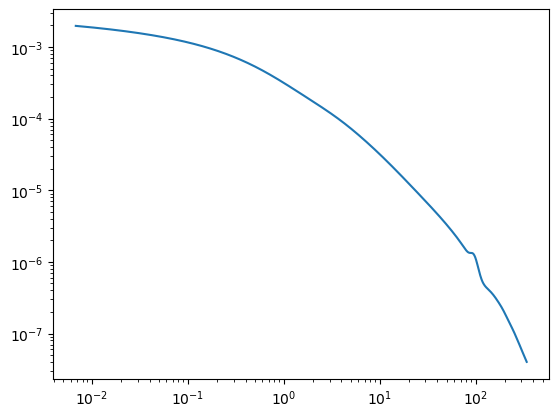

In [13]:
plt.loglog(r_wpp, wpp_casper, label='Casper w_pp')

# Multipoles with FFTLog

In [14]:
import pyccl as ccl

import src.galaxy_alignment_prediction_tool.multipoles
import src.galaxy_alignment_prediction_tool.powerspectrum
import src.galaxy_alignment_prediction_tool.projections

# Reload to update changes
import importlib
importlib.reload(src.galaxy_alignment_prediction_tool.multipoles)
importlib.reload(src.galaxy_alignment_prediction_tool.powerspectrum)
importlib.reload(src.galaxy_alignment_prediction_tool.projections)

from src.galaxy_alignment_prediction_tool.multipoles import multipoles
from src.galaxy_alignment_prediction_tool.powerspectrum import powerSpectrum
from src.galaxy_alignment_prediction_tool.projections import projections

In [15]:
powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

In [16]:
k_input = np.geomspace(1e-5, 500, 1000)
cosmology = ccl.Cosmology(**cosmology_dict)

pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
    cosmo=cosmology,
    k_input=k_input,
    redshift=0.,
    pk_type='nonlinear_matter'
)

pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=0.
)

pkpp = powerSpectrumHandler.convert_pk_matter_to_pk_plusplus(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=0.
)

pkgp_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkgp,
)

pkgg_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkmm_ccl,
)

pkpp_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkpp,
)

In [17]:
r_xigp_list, xigp_list, ells_gp = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgp_spline,
    probe_type='g+',
)

r_xigg_list, xigg_list, ells_gg = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgg_spline,
    probe_type='gg',
)

r_xipp_list, xipp_list, ells_pp = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkpp_spline,
    probe_type='++',
)

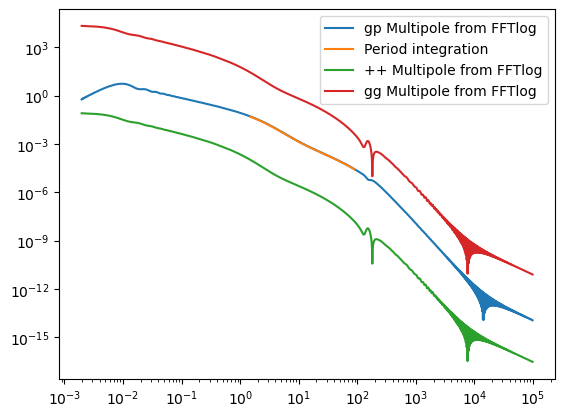

In [18]:
plt.loglog(r_xigp_list[0], np.abs(xigp_list[0]), label='gp Multipole from FFTlog')
plt.loglog(r_period/cosmology_dict['h'], xi_period, label='Period integration')

plt.loglog(r_xipp_list[0], np.abs(xipp_list[0]), label='++ Multipole from FFTlog')
plt.loglog(r_xigg_list[0], np.abs(xigg_list[0]), label='gg Multipole from FFTlog')
plt.legend()
plt.show()
plt.close()

### Test conversion to projections

In [19]:
rp = np.geomspace(interpolation_settings['r_min_over_h'], interpolation_settings['r_max_over_h'], interpolation_settings['number_of_points'])/cosmology_dict['h']
pimax = simulation_settings['pi_max_over_h']/cosmology_dict['h']

w_gp = projectionsHandler.convert_multipoles_to_projected_correlation_function(
    r_list=r_xigp_list,
    xi_ell_list=xigp_list,
    ell_list=ells_gp,
    spin=2,
    rp_array=rp,
    pi_max=pimax,
)

w_gg = projectionsHandler.convert_multipoles_to_projected_correlation_function(
    r_list=r_xigg_list,
    xi_ell_list=xigg_list,
    ell_list=ells_gg,
    spin=0,
    rp_array=rp,
    pi_max=pimax,
)

w_pp = projectionsHandler.convert_multipoles_to_projected_correlation_function(
    r_list=r_xipp_list,
    xi_ell_list=xipp_list,
    ell_list=ells_pp,
    spin=4,
    rp_array=rp,
    pi_max=pimax,
)

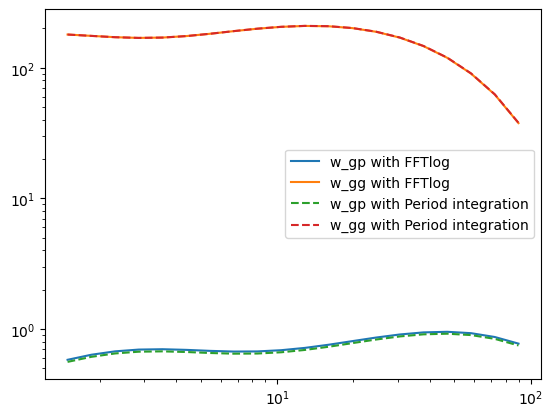

In [20]:
plt.loglog(rp, rp*w_gp, label='w_gp with FFTlog')
plt.loglog(rp, rp*w_gg, label='w_gg with FFTlog')
# plt.loglog(rp, w_pp, label='w_++ with FFTlog')
plt.loglog(r_period/cosmology_dict['h'], r_period*wgp_period/cosmology_dict['h']**2, label='w_gp with Period integration', linestyle='--')
plt.loglog(r_period/cosmology_dict['h'], r_period*wgg_period/cosmology_dict['h']**2, label='w_gg with Period integration', linestyle='--')
# plt.loglog(r_wpp/cosmology_dict['h'], wpp_casper/cosmology_dict['h'], label='w_++ from Casper', linestyle='--')
plt.legend()
plt.show()
plt.close()

### Full speedtest to get all multipoles and projections from a ccl power spectrum

In [24]:
from time import time

powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

k_input = np.geomspace(1e-5, 500, 1000)
cosmology = ccl.Cosmology(**cosmology_dict)

time_start = time()

pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
    cosmo=cosmology,
    k_input=k_input,
    redshift=0.,
    pk_type='nonlinear_matter'
)

time_ccl = time()
print("CCL power spectrum calculation took", time_ccl-time_start, "s")

pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=0.
)

pkpp = powerSpectrumHandler.convert_pk_matter_to_pk_plusplus(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=0.
)

pkgp_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkgp,
)

pkgg_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkmm_ccl,
)

pkpp_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkpp,
)

r_xigp_list, xigp_list, ells_gp = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgp_spline,
    probe_type='g+',
)

r_xigg_list, xigg_list, ells_gg = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgg_spline,
    probe_type='gg',
)

r_xipp_list, xipp_list, ells_pp = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkpp_spline,
    probe_type='++',
)

rp = np.geomspace(interpolation_settings['r_min_over_h'], interpolation_settings['r_max_over_h'], interpolation_settings['number_of_points'])/cosmology_dict['h']
pimax = simulation_settings['pi_max_over_h']/cosmology_dict['h']

w_gp = projectionsHandler.project_multipole_to_2d_correlation_function(
    r_list=r_xigp_list,
    xi_ell_list=xigp_list,
    ell_list=ells_gp,
    spin=2,
    rp_array=rp,
    pi_max=pimax,
)

w_gg = projectionsHandler.project_multipole_to_2d_correlation_function(
    r_list=r_xigg_list,
    xi_ell_list=xigg_list,
    ell_list=ells_gg,
    spin=0,
    rp_array=rp,
    pi_max=pimax,
)

w_pp = projectionsHandler.project_multipole_to_2d_correlation_function(
    r_list=r_xipp_list,
    xi_ell_list=xipp_list,
    ell_list=ells_pp,
    spin=4,
    rp_array=rp,
    pi_max=pimax,
)

time_end = time()

print("Total FFTlog based calculation took", time_end-time_start, "s")
print("Which is broken down into:")
print("- CCL power spectrum calculation:", time_ccl-time_start, "s")
print("- Multipole calculation and projection:", time_end-time_ccl, "s")

CCL power spectrum calculation took 0.2866356372833252 s


AttributeError: 'projections' object has no attribute 'project_multipole_to_2d_correlation_function'

# Test higher redshift predictions

## From Christos

In [21]:
import pyccl as ccl
import numpy as np
from scipy.integrate import simpson
from scipy.special import jv
import matplotlib.pyplot as plt
from tqdm import tqdm

In [29]:
size_factor = 32

def compute_wgg(cosmo, r_p, Pi_max, z):
    k_par_arr = np.geomspace(1e-6, 1e2, size_factor * 1024)
    k_perp_arr = np.geomspace(1e-4, 1e2, size_factor * 1024)
    k_dot_r = np.outer(r_p, k_perp_arr)

    sinkPimax = np.sin(Pi_max*k_par_arr)
    wkpar_integral = np.empty(len(k_perp_arr))
    for i, k_perp in tqdm(enumerate(k_perp_arr), total=len(k_perp_arr)):
        k_tot_arr = np.sqrt(k_perp**2.+k_par_arr**2.)
        wkpar_integrand = cosmo.nonlin_matter_power(k_tot_arr, 1/(1+z)) * sinkPimax / k_par_arr
        wkpar_integral[i] = simpson(wkpar_integrand, k_par_arr)

    w_integrand = wkpar_integral*k_perp_arr*jv(0,k_dot_r)

    return simpson(w_integrand, k_perp_arr)/np.pi**2


def compute_wgp(cosmo, r_p, Pi_max, z):
    k_par_arr = np.geomspace(1e-6, 1e3, size_factor*1024)
    k_perp_arr = np.geomspace(1e-6, 1e3, size_factor*1024)
    # k_par_arr = np.geomspace(1e-5, 1e2, 8*1024)
    # k_perp_arr = np.geomspace(1e-5, 1e2, 8*1024)
    
    sinkPimax = np.sin(Pi_max*k_par_arr)

    # Compute the integral in k_\parallel
    wkpar_integral = np.empty(len(k_perp_arr))
    for i, k_perp in tqdm(enumerate(k_perp_arr), total=len(k_perp_arr)):
        k_tot_arr = np.sqrt(k_perp**2.+k_par_arr**2.)

        wkpar_integrand = cosmo.nonlin_matter_power(k_tot_arr, 1/(1+z)) * sinkPimax / ((k_tot_arr)**2*k_par_arr)
        wkpar_integral[i] = simpson(wkpar_integrand, k_par_arr)

    # Complete the integration in k_\perp.
    k_dot_r = np.outer(r_p, k_perp_arr)
    w_integrand = wkpar_integral*k_perp_arr**3*jv(2,k_dot_r)

    # C1rhocrit = 5e-14 * ccl.physical_constants.RHO_CRITICAL
    C1rhocrit = 0.0134
    w = C1rhocrit*cosmo['Omega_m']/cosmo.growth_factor(1/(1+z))*simpson(w_integrand, k_perp_arr)/np.pi**2
    return w

def compute_wpp(cosmo, r_p, Pi_max, z):
    k_par_arr = np.geomspace(1e-6, 1e3, 8*1024)
    k_perp_arr = np.geomspace(1e-6, 1e3, 8*1024)

    sinkPimax = np.sin(Pi_max*k_par_arr)

    # Compute the integral in k_\parallel
    wkpar_integral = np.empty(len(k_perp_arr))
    for i, k_perp in tqdm(enumerate(k_perp_arr)):
        k_tot_arr = np.sqrt(k_perp**2.+k_par_arr**2.)

        wkpar_integrand = cosmo.nonlin_matter_power(k_tot_arr, 1/(1+z)) * sinkPimax / ((k_tot_arr)**4*k_par_arr)
        wkpar_integral[i] = simpson(wkpar_integrand, k_par_arr)

    # Complete the integration in k_\perp.
    k_dot_r = np.outer(r_p, k_perp_arr)
    w_integrand = wkpar_integral*k_perp_arr**5*(jv(0,k_dot_r)+jv(4,k_dot_r))

    C1rhocrit = 5e-14 * ccl.physical_constants.RHO_CRITICAL
    w = (C1rhocrit*cosmo['Omega_m']/cosmo.growth_factor(1/(1+z)))**2*simpson(w_integrand, k_perp_arr)/(2*np.pi**2)
    return w

In [30]:
cosmo_dict = cosmology_dict
cosmo = ccl.Cosmology(**cosmo_dict)

rp_christos = np.geomspace(0.1/cosmo_dict["h"], 150/cosmo_dict["h"], 50)
# Pi_max = 20/cosmo_dict["h"]
Pi_max = 50/cosmo_dict["h"]
z = 3.0

In [31]:
wgg_christos = compute_wgg(cosmo, rp_christos, Pi_max, z)
wgp_christos = compute_wgp(cosmo, rp_christos, Pi_max, z)
# wpp = compute_wpp(cosmo, r_p, Pi_max, z)

  0%|          | 0/32768 [00:00<?, ?it/s]

100%|██████████| 32768/32768 [03:03<00:00, 178.62it/s]


## From Me

In [32]:
powerSpectrumHandler = powerSpectrum()
multipolesHandler = multipoles()
projectionsHandler = projections()

k_input = np.geomspace(1e-5, 500, 1000)

pkmm_ccl = powerSpectrumHandler.ccl_power_spectrum(
    cosmo=cosmology,
    k_input=k_input,
    redshift=z,
    pk_type='nonlinear_matter'
)

pkgp = powerSpectrumHandler.convert_pk_matter_to_pk_gplus(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=z
)

pkgg = powerSpectrumHandler.convert_pk_matter_to_pk_gg(
    pk_matter=pkmm_ccl,
    cosmo=cosmology,
    redshift=z
)

pkgp_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkgp,
)

pkgg_spline = powerSpectrumHandler.power_spectrum_spline(
    k_input=k_input,
    pk_input=pkgg,
)

r_xigp_list, xigp_list, ells_gp = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgp_spline,
    probe_type='g+',
)

r_xigg_list, xigg_list, ells_gg = multipolesHandler.return_all_multipoles_from_power_spectrum(
    power_spectrum_spline=pkgg_spline,
    probe_type='gg',
)

rp = rp_christos
pimax = Pi_max

w_gp = projectionsHandler.convert_multipoles_to_projected_correlation_function(
    r_list=r_xigp_list,
    xi_ell_list=xigp_list,
    ell_list=ells_gp,
    spin=2,
    rp_array=rp,
    pi_max=pimax,
)

w_gg = projectionsHandler.convert_multipoles_to_projected_correlation_function(
    r_list=r_xigg_list,
    xi_ell_list=xigg_list,
    ell_list=ells_gg,
    spin=0,
    rp_array=rp,
    pi_max=pimax,
)

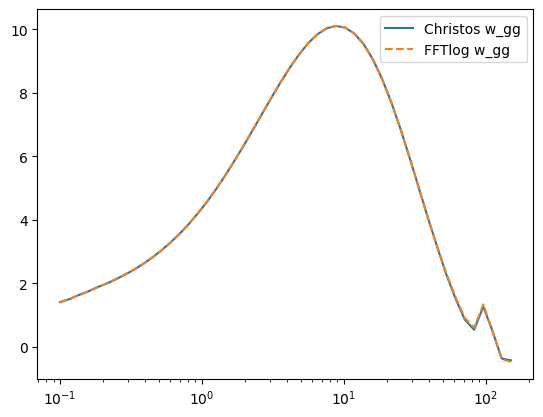

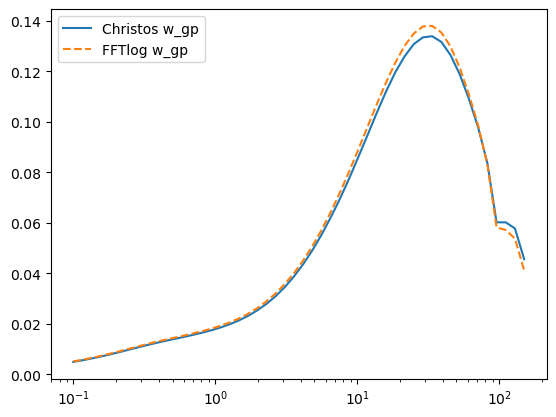

In [33]:
plt.semilogx(rp_christos*cosmo_dict['h'], rp_christos*wgg_christos*cosmo_dict['h']**2, label='Christos w_gg')
plt.semilogx(rp*cosmo_dict['h'], rp*w_gg*cosmo_dict['h']**2, label='FFTlog w_gg', linestyle='--')
plt.legend()
plt.show()
plt.close()

plt.semilogx(rp_christos*cosmo_dict['h'], rp_christos*wgp_christos*cosmo_dict['h']**2, label='Christos w_gp')
plt.semilogx(rp*cosmo_dict['h'], rp*w_gp*cosmo_dict['h']**2, label='FFTlog w_gp', linestyle='--')
plt.legend()
plt.show()
plt.close()